In [40]:
import pandas as pd

df = pd.read_csv("AB_NYC_2019.csv")

print(df.shape)
df.head()


(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [41]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [42]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [43]:
df = df.dropna(subset=["name", "host_name"])

In [44]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [45]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [46]:
import sqlite3

In [47]:
conn = sqlite3.connect(":memory:")

In [48]:
df.to_sql("listings", conn, index=False, if_exists="replace")

48858

In [49]:
query = "SELECT * FROM listings LIMIT 5"
result = pd.read_sql(query, conn)
result

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,None,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [50]:
query = """
SELECT neighbourhood_group, COUNT(*) as total_listings
FROM listings
GROUP BY neighbourhood_group
ORDER BY total_listings DESC
"""
result = pd.read_sql(query, conn)
print(result)

  neighbourhood_group  total_listings
0           Manhattan           21643
1            Brooklyn           20089
2              Queens            5664
3               Bronx            1089
4       Staten Island             373


In [51]:
query = """
SELECT neighbourhood_group,
       AVG(price) as avg_price,
       COUNT(*) as total_listings
FROM listings
GROUP BY neighbourhood_group
ORDER BY avg_price DESC
"""

result = pd.read_sql(query, conn)
print(result)


  neighbourhood_group   avg_price  total_listings
0           Manhattan  196.897473           21643
1            Brooklyn  124.410523           20089
2       Staten Island  114.812332             373
3              Queens   99.536017            5664
4               Bronx   87.469238            1089


In [52]:
query = """
SELECT room_type,
       COUNT(*) AS total_listings,
       AVG(price) as avg_price
FROM listings
GROUP BY room_type
ORDER BY total_listings DESC
"""

result = pd.read_sql(query, conn)
print(result)

         room_type  total_listings   avg_price
0  Entire home/apt           25393  211.806994
1     Private room           22306   89.794360
2      Shared room            1159   70.075928


In [53]:
query = """
SELECT neighbourhood_group, neighbourhood, AVG(price) as avg_price
FROM listings
GROUP BY neighbourhood_group, neighbourhood
ORDER BY neighbourhood_group, avg_price DESC
"""

result = pd.read_sql(query, conn)
print(result.head(20))

   neighbourhood_group       neighbourhood   avg_price
0                Bronx           Riverdale  442.090909
1                Bronx         City Island  173.000000
2                Bronx      Spuyten Duyvil  154.750000
3                Bronx         Eastchester  141.692308
4                Bronx           Unionport  137.142857
5                Bronx  Westchester Square  122.200000
6                Bronx          West Farms  122.000000
7                Bronx            Van Nest  113.818182
8                Bronx        Clason Point  112.761905
9                Bronx          Pelham Bay  105.000000
10               Bronx      Williamsbridge   96.750000
11               Bronx      Pelham Gardens   93.607143
12               Bronx            Longwood   91.919355
13               Bronx         Throgs Neck   91.041667
14               Bronx          Mott Haven   88.916667
15               Bronx            Allerton   87.595238
16               Bronx   Claremont Village   87.464286
17        

In [54]:
query = """
SELECT neighbourhood_group, neighbourhood, avg_price, rank
FROM (
    SELECT
        neighbourhood_group,
        neighbourhood,
        AVG(price) as avg_price,
        RANK() OVER (PARTITION BY neighbourhood_group ORDER BY AVG(price) DESC) as rank
    FROM listings
    GROUP BY neighbourhood_group, neighbourhood
)
WHERE rank = 1
"""

result = pd.read_sql(query, conn)
print(result)

  neighbourhood_group   neighbourhood   avg_price  rank
0               Bronx       Riverdale  442.090909     1
1            Brooklyn        Sea Gate  487.857143     1
2           Manhattan         Tribeca  490.638418     1
3              Queens        Neponsit  274.666667     1
4       Staten Island  Fort Wadsworth  800.000000     1


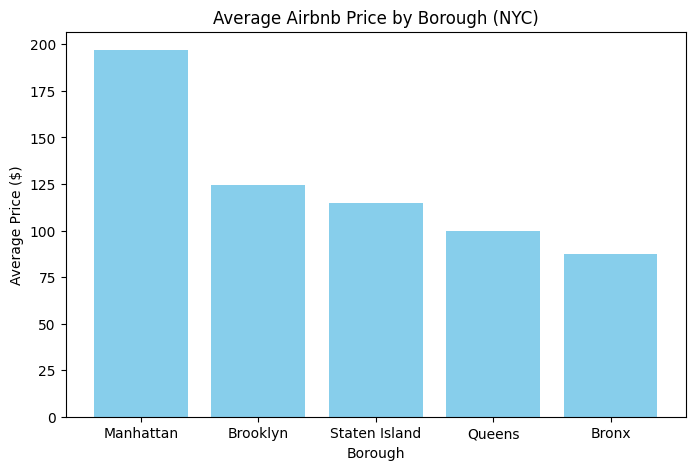

In [55]:
query = """
SELECT neighbourhood_group, AVG(price) as avg_price
FROM listings
GROUP BY neighbourhood_group
ORDER BY avg_price DESC
"""
result = pd.read_sql(query, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(result["neighbourhood_group"], result["avg_price"], color="skyblue")
plt.title("Average Airbnb Price by Borough (NYC)")
plt.xlabel("Borough")
plt.ylabel("Average Price ($)")
plt.show()

**Key Findings**

1. Manhattan and Brooklyn dominate the NYC Airbnb market, accounting for nearly 85% of all listings (21,643 and 20,089 listings respectively).

2. Manhattan has the highest average price (USD 196.90 night), more than double that of the Bronx (USD 87.47 night).

3. Entire home/apt is both the most common (25,393 listings) and most expensive room type (USD 211.81/night on average), while Shared rooms are the least common and cheapest (USD 70.08/night).

4. Borough-level averages can hide extreme outliers at the neighborhood level: while Stalen Island has the lowest average price in the entire city (USD 800/night), even surpassing Manhattan's Tribeca (USD 490.64/night).


**Conclusion**

This analysis of NYC Airbnb listings reveals a market heavily concentrated in Manhattan and Brooklyn, with clear pricing differences driven by both borough location and room type. While Manhattan has the highest average price overall, a closer look at the neighborhood level reveals that Fort Wadsworth in Stalen Island has the highest average listing price in the dataset. This demonstrates that borough-level averages do not always reflect local market conditions. Combining SQL queries, including the RANK() window function, with pandas made it possible to identify these patterns and gain more detailed insights into the data.